**Author:** Tianqi Shen & GPT-4o

**Date:** 29 May 2026

# Empirical Evidence for Muon as an Early Exploration Optimizer
## Empirical Evidence in Vision Model's Image Representation

The optimization geometry of Burer-Monteiro (BM) factorized matrix sensing is directly shaped by the sensing distribution: each sample corresponds to a sensing matrix $A_i$, and the square gradient is proportional to $\mathcal{A}^*\mathcal{A}(XX^\top-M^\star)$. Therefore if we make our sensing matrices to be anisotropic, so will the gradients and Hessians. This act is motivated by our empirical evidence for a mixed-spiked covariance structure in image representations.

In [1]:
%matplotlib inline
#import matplotlib_inline   # setup output image format, do not use 'svg' if need 'pdf' output
#matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 300
import math
import random
import matplotlib
import argparse
import numpy as np
import torch
import torch.nn as nn
from dataclasses import dataclass
from typing import List, Tuple, Dict, Any
from itertools import chain
from tqdm import tqdm
from torch.utils.data import DataLoader, ConcatDataset
from torchvision import datasets, transforms, models
from matplotlib.lines import Line2D

@dataclass
class ExperimentConfig:
    dataset: str
    backbone: str
    max_samples: int
    batch_size: int = 256
    num_workers: int = 4

def set_seed(seed: int = 0) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
set_seed(1103)
DATA_ROOT = "./data"
SIGNAL_R2_THRESH = 0.5
DEVICE = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cuda', index=3)

### Functions for loading datasets and performing data preprocessing
- **Small scale (CIFAR-10):** CIFAR-10 is a small-scale, low-resolution (32×32) benchmark of 60,000 natural images across 10 classes, widely used for rapid evaluation of image classification methods.
- **Large scale (STL-10):** STL-10 is a more challenging dataset with higher-resolution (96×96) images and a larger pool of unlabeled data, designed to evaluate representation learning and classification under limited labeled supervision.

In [2]:
def imagenet_transform() -> transforms.Compose:
    return transforms.Compose([
        transforms.Resize(224),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=(0.485, 0.456, 0.406),
            std=(0.229, 0.224, 0.225),
        ),
    ])

def get_dataset(name: str):
    tfm = imagenet_transform()

    if name.lower() == "cifar10":
        ds = datasets.CIFAR10(
            root=DATA_ROOT,
            train=True,
            download=True,
            transform=tfm,
        )
        num_classes = 10
        display_name = "CIFAR-10"
        return ds, num_classes, display_name

    if name.lower() == "stl10":
        ds_train = datasets.STL10(
            root=DATA_ROOT,
            split="train",
            download=True,
            transform=tfm,
        )
        ds_test = datasets.STL10(
            root=DATA_ROOT,
            split="test",
            download=True,
            transform=tfm,
        )
        ds = ConcatDataset([ds_train, ds_test])
        num_classes = 10
        display_name = "STL-10"
        return ds, num_classes, display_name

    raise ValueError(f"Unknown dataset: {name}")

### Functions for loading backbone models
- **Small scale (ResNet-18):** ResNet-18 is a lightweight residual CNN backbone that provides strong baseline performance with low computational overhead, making it suitable for small-scale image classification.
- **Large scale (SwinV2-B):** SwinV2-B is a high-capacity hierarchical Vision Transformer backbone with shifted-window self-attention, enabling scalable modeling of high-resolution imagery and strong large-scale visual recognition performance.

In [3]:
class ResNet18Features(nn.Module):
    def __init__(self):
        super().__init__()
        weights = models.ResNet18_Weights.DEFAULT
        model = models.resnet18(weights=weights)
        self.backbone = nn.Sequential(*list(model.children())[:-1])

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        z = self.backbone(x)
        return z.flatten(1)

class SwinV2BFeatures(nn.Module):
    def __init__(self):
        super().__init__()
        weights = models.Swin_V2_B_Weights.DEFAULT
        model = models.swin_v2_b(weights=weights)
        model.head = nn.Identity()
        self.backbone = model

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.backbone(x)

def get_feature_model(backbone: str) -> Tuple[nn.Module, str]:
    backbone = backbone.lower()

    if backbone == "resnet18":
        return ResNet18Features(), "ResNet-18"

    if backbone == "swin_v2_b":
        return SwinV2BFeatures(), "SwinV2-B"

    raise ValueError(f"Unknown backbone: {backbone}")

### Functions for extracting and standardizing vision features

In [4]:
@torch.no_grad()
def extract_features(
    ds,
    model: nn.Module,
    batch_size: int,
    max_samples: int,
    num_workers: int,
) -> Tuple[torch.Tensor, torch.Tensor]:
    loader = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
    )

    model = model.to(DEVICE).eval()

    feats = []
    labels = []
    seen = 0

    for batch in loader:
        x, y = batch[0], batch[1]
        x = x.to(DEVICE, non_blocking=True)

        z = model(x).detach().cpu()
        feats.append(z)

        if torch.is_tensor(y):
            labels.append(y.cpu())
        else:
            labels.append(torch.tensor(y))

        seen += z.shape[0]
        if max_samples is not None and seen >= max_samples:
            break

    X = torch.cat(feats, dim=0)
    y = torch.cat(labels, dim=0).long()

    if max_samples is not None and X.shape[0] > max_samples:
        X = X[:max_samples]
        y = y[:max_samples]

    return X, y

def standardize_features(X: torch.Tensor) -> torch.Tensor:
    mu = X.mean(dim=0, keepdim=True)
    sd = X.std(dim=0, keepdim=True, unbiased=False).clamp_min(1e-6)
    return (X - mu) / sd

### Functions for analysis
Below we interpret the spectrum of the (standardized) feature covariance through a random-matrix baseline. Let $C=\frac{ZZ^\top}{n}$, where $Z$ denotes standardized features and $q=\frac{d}{n}$ is the aspect ratio. Under a noise-only (isotropic) model, the eigenvalues of $C$ concentrate within the Marchenko-Pastur (MP) bulk, whose upper edge is $\lambda_+=(1+\sqrt{q})^2$. Consequently, eigenvalues below $\lambda_+$ are treated as **bulk** (or background-noise) components. Eigenvalues exceeding $\lambda_+$ are termed outliers and indicate directions of non-random structure in the representation. 

Importantly, structural outliers are not necessarily task-relevant. To separate task-related structure from label-agnostic structure, we project features onto each outlier eigenvector and compute a one-way ANOVA effect size $R^2$, defined as the ratio of between-class variance to total variance of the resulting scores. Outlier components with large ANOVA $R^2$ are interpreted as **signal** directions aligned with the supervised labels, whereas outliers with small $R^2$ are treated as label-independent **spikes** that capture structure unrelated to the target task.

In [5]:
def mp_edges(n: int, d: int) -> Tuple[float, float, float]:
    """
    Compute the Marchenko–Pastur (MP) bulk support for a sample covariance matrix.

    Under the classical random matrix model, if Z \in R^{n x d} has i.i.d. entries with
    zero mean and unit variance (after appropriate feature standardization), then the
    empirical eigenvalue distribution of (Z^T Z)/n converges to the MP law as n,d -> inf
    with aspect ratio q = d/n fixed. The bulk is supported on:
        lambda_- = (1 - sqrt(q))^2,  lambda_+ = (1 + sqrt(q))^2.

    Parameters
    ----------
    n : int
        Number of samples.
    d : int
        Feature dimension.
    Returns
    -------
    lambda_minus : float
        Lower edge of the MP bulk.
    lambda_plus : float
        Upper edge of the MP bulk.
    q : float
        Aspect ratio d/n.
    """
    if n <= 0 or d <= 0:
        raise ValueError("Both n and d must be positive integers.")
    q = d / n
    sqrt_q = math.sqrt(q)
    lambda_minus = (1.0 - sqrt_q) ** 2
    lambda_plus = (1.0 + sqrt_q) ** 2
    return lambda_minus, lambda_plus, q

def anova_r2(scores: torch.Tensor, y: torch.Tensor, num_classes: int) -> float:
    """
    One-way ANOVA effect size (R^2) for a univariate score with respect to class labels.

    Given scores s_i (e.g., PC scores along a single component) and labels y_i in
    {0, ..., C-1}, we compute:
        R^2 = Var_between / Var_total,
    where Var_between is the variance explained by class-conditional mean shifts.

    This quantity measures how much of the score variance can be attributed to class
    membership, without assuming any specific classifier.

    Parameters
    ----------
    scores : torch.Tensor, shape [n]
        Univariate scores for n samples.
    y : torch.Tensor, shape [n]
        Integer class labels for n samples.
    num_classes : int
        Total number of classes C.

    Returns
    -------
    float
        ANOVA R^2 in [0, 1] (up to numerical error). Returns 0.0 if total variance is
        numerically zero.
    """
    if scores.ndim != 1:
        raise ValueError(f"`scores` must be 1D of shape [n], got {tuple(scores.shape)}.")
    if y.ndim != 1:
        raise ValueError(f"`y` must be 1D of shape [n], got {tuple(y.shape)}.")
    if scores.shape[0] != y.shape[0]:
        raise ValueError("`scores` and `y` must have the same length.")
    if num_classes <= 0:
        raise ValueError("`num_classes` must be a positive integer.")

    s = scores.float()
    y = y.long()

    s_mean = s.mean()
    var_total = ((s - s_mean) ** 2).mean().item()
    if var_total <= 1e-12:
        return 0.0

    # Between-class variance: sum_c p(c) * (mean_c - global_mean)^2
    var_between = 0.0
    for c in range(num_classes):
        mask = (y == c)
        if mask.any():
            p_c = mask.float().mean().item()
            mean_c = s[mask].mean()
            var_between += p_c * float((mean_c - s_mean) ** 2)

    return float(var_between / var_total)

def compute_spectrum_and_outliers(
    X: torch.Tensor,
    y: torch.Tensor,
    num_classes: int,
) -> Dict[str, Any]:
    """
    Spectral analysis of the feature covariance with MP-based outlier detection,
    followed by label-alignment quantification via ANOVA R^2.

    Pipeline
    --------
    1) Standardize features: Z = standardize_features(X).
    2) Form sample covariance: C = (Z^T Z)/n.
    3) Eigendecompose C to obtain eigenvalues/eigenvectors (principal components).
    4) Identify spectral outliers as eigenvalues exceeding the MP upper edge lambda_+.
    5) For each outlier component v_j, compute PC scores s_j = Z v_j and quantify
       label alignment using one-way ANOVA R^2 against y.

    Notes
    -----
    - The MP threshold is a model-based baseline for separating bulk (background-noise-like)
      spectrum from components that carry non-random structure.
    - An outlier component is not necessarily task-relevant; ANOVA R^2 is used to
      distinguish label-aligned signal from label-agnostic spikes.

    Parameters
    ----------
    X : torch.Tensor, shape [n, d]
        Feature matrix (n samples, d-dimensional features).
    y : torch.Tensor, shape [n]
        Class labels.
    num_classes : int
        Number of classes.

    Returns
    -------
    Dict[str, Any]
        n, d, q, lambda_minus, lambda_plus,
        evals (descending, numpy),
        outlier_idx (numpy indices into evals),
        outlier_evals (numpy),
        outlier_r2 (numpy; ANOVA R^2 per outlier component).
    """
    if X.ndim != 2:
        raise ValueError(f"`X` must be 2D of shape [n, d], got {tuple(X.shape)}.")
    if y.ndim != 1:
        raise ValueError(f"`y` must be 1D of shape [n], got {tuple(y.shape)}.")
    if X.shape[0] != y.shape[0]:
        raise ValueError("`X` and `y` must have compatible first dimension (n).")

    # Feature standardization is assumed to make dimensions comparable and compatible
    # with the MP baseline (e.g., approximately zero-mean/unit-variance per feature).
    Z = standardize_features(X)
    n, d = Z.shape

    # Sample covariance in feature space.
    C = (Z.T @ Z) / float(n)

    # Symmetric eigendecomposition (ascending eigenvalues).
    evals, evecs = torch.linalg.eigh(C)

    # Reorder into descending eigenvalues for convenience.
    evals = evals.flip(0).contiguous()
    evecs = evecs.flip(1).contiguous()

    lambda_minus, lambda_plus, q = mp_edges(n, d)

    # MP-based outlier detection: eigenvalues above the bulk upper edge.
    outlier_mask = evals > lambda_plus
    outlier_idx = torch.where(outlier_mask)[0].detach().cpu().numpy()
    inlier_idx = torch.where(~outlier_mask)[0].detach().cpu().numpy()
    outlier_evals = evals[outlier_idx]
    inlier_evals = evals[inlier_idx]
    outlier_vecs = evecs[:, outlier_idx]  # shape [d, k]

    # PC scores for the outlier subspace: shape [n, k]
    outlier_scores = Z @ outlier_vecs

    # Label alignment per outlier component.
    outlier_r2 = [
        anova_r2(outlier_scores[:, j], y, num_classes)
        for j in range(outlier_scores.shape[1])
    ]
    outlier_r2 = np.asarray(outlier_r2, dtype=np.float64)

    return {
        "n": int(n),
        "d": int(d),
        "q": float(q),
        "lambda_minus": float(lambda_minus),
        "lambda_plus": float(lambda_plus),
        "evals": evals.detach().cpu().numpy(),
        "outlier_idx": outlier_idx,
        "inlier_idx": inlier_idx,
        "outlier_evals": outlier_evals.detach().cpu().numpy(),
        "inlier_evals": inlier_evals.detach().cpu().numpy(),
        "outlier_r2": outlier_r2,
    }

### Functions for running an experiment

In [6]:
def run_or_load_experiment(cfg: ExperimentConfig) -> Dict[str, Any]:

    print(f"[run] dataset={cfg.dataset}, backbone={cfg.backbone}")
    ds, num_classes, dataset_display = get_dataset(cfg.dataset)
    model, backbone_display = get_feature_model(cfg.backbone)

    X, y = extract_features(
        ds=ds,
        model=model,
        batch_size=cfg.batch_size,
        max_samples=cfg.max_samples,
        num_workers=cfg.num_workers,
    )

    stats = compute_spectrum_and_outliers(X, y, num_classes)
    stats.update({
        "dataset": cfg.dataset,
        "dataset_display": dataset_display,
        "backbone": cfg.backbone,
        "backbone_display": backbone_display,
        "num_classes": num_classes,
        "max_samples": cfg.max_samples,
    })

    return stats

### Run the small-scale experiment and visualize results
- ResNet-18 + CIFAR-10

In [7]:
cfg1 = ExperimentConfig(
    dataset="cifar10",
    backbone="resnet18",
    max_samples=10000,
    batch_size=256,
    num_workers=4,
)
stats1 = run_or_load_experiment(cfg1)

n1, d1, q1 = stats1['n'], stats1['d'], stats1['q']
evals1 = stats1["evals"]
outlier1_evals = stats1["outlier_evals"]
inlier1_evals = stats1["inlier_evals"]
outlier1_r2 = stats1["outlier_r2"]
lambda1_plus = stats1["lambda_plus"]

num_outliers1 = len(outlier1_evals)
num_inliers1 = len(inlier1_evals)
max_ratio1 = float(evals1[0] / lambda1_plus)
num_signal1 = int(np.sum(outlier1_r2 >= SIGNAL_R2_THRESH))
num_spike1 = int(np.sum(outlier1_r2 < SIGNAL_R2_THRESH))

print(
    f"{stats1['dataset_display']} / {stats1['backbone_display']}: "
    f"n={n1}, d={d1}, q={q1:.4f}, "
    f"lambda_plus={lambda1_plus:.4f}, "
    f"max(lambda/lambda_plus)={max_ratio1:.2f},\n"
    f"bulk(or background_noise)={num_inliers1}, outliers={num_outliers1}, "
    f"signal={num_signal1}, nuisance_spike={num_spike1}"
)

ratio1 = evals1 / lambda1_plus
ranks1 = np.arange(1, len(evals1) + 1)
rank_frac1 = ranks1 / d1  # ranks are also normalized
is_outlier1 = ratio1 > 1.0
x1 = outlier1_evals / lambda1_plus
y1 = outlier1_r2
strong1 = y1 >= SIGNAL_R2_THRESH
weak1 = ~strong1

[run] dataset=cifar10, backbone=resnet18
Files already downloaded and verified
CIFAR-10 / ResNet-18: n=10000, d=512, q=0.0512, lambda_plus=1.5037, max(lambda/lambda_plus)=25.80,
bulk(or background_noise)=434, outliers=78, signal=1, nuisance_spike=77


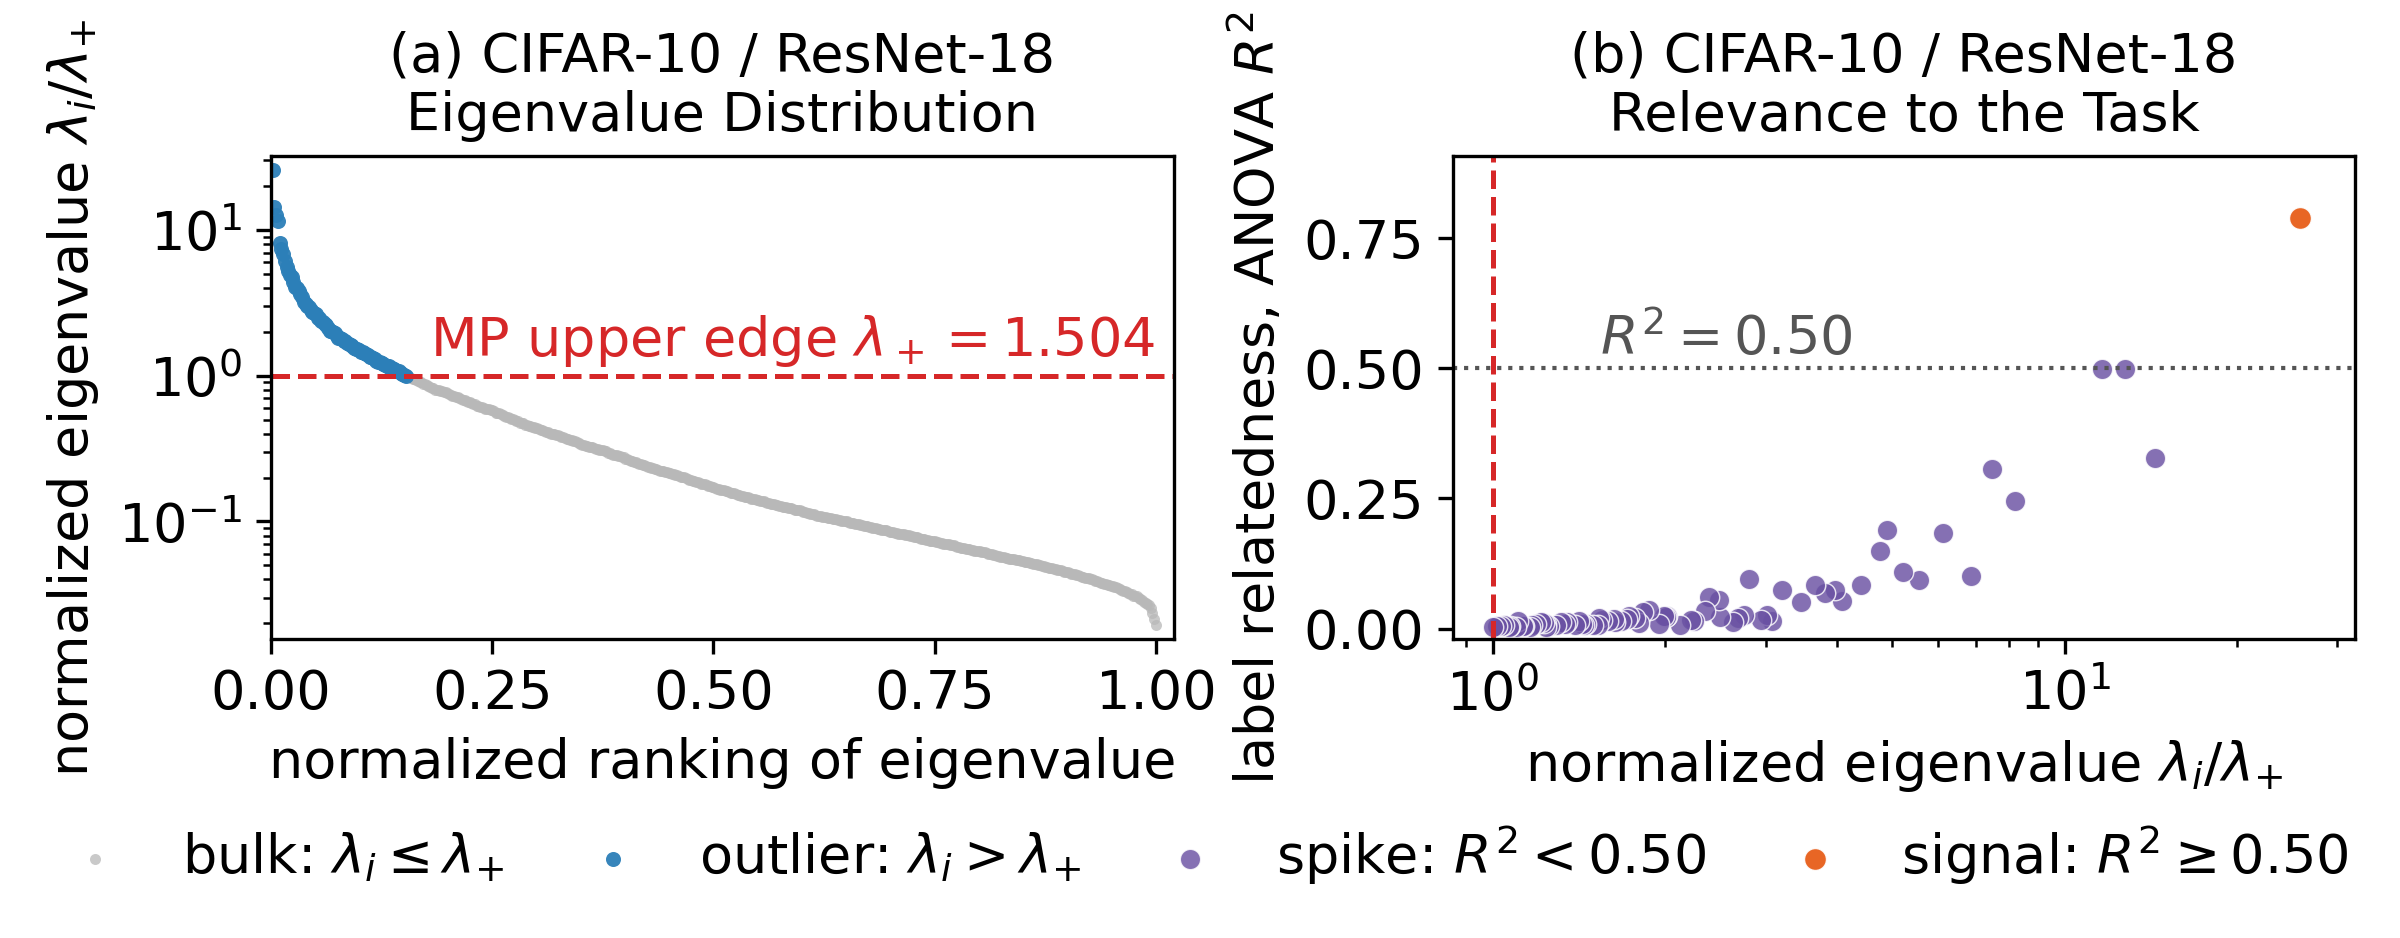

Saved figure to: empirical_evidence_in_image_representation_small.pdf


In [8]:
fig1, (ax1_1, ax1_2) = plt.subplots(1, 2, figsize=(8, 3.2), gridspec_kw=dict(width_ratios=[1.0, 1.0]))

# Bulk / background noise eigenvalues
ax1_1.scatter(rank_frac1[~is_outlier1], ratio1[~is_outlier1],
              s=7, c="#b8b8b8", alpha=0.75, linewidths=0, rasterized=True,
              label=r"bulk: $\lambda_i \leq \lambda_{+}$",)
# Spectral outliers
ax1_1.scatter(rank_frac1[is_outlier1], ratio1[is_outlier1],
              s=13, c="#2c7fb8", alpha=0.95, linewidths=0, rasterized=True,
              label=r"outlier: $\lambda_i > \lambda_{+}$",)
# Marchenko–Pastur (MP) upper edge, normalized to 1
ax1_1.axhline(1.0, color="#d62728", ls="--", lw=1.2)
# Annotate the original, unnormalized MP upper edge. Since y-axis is lambda_i / lambda_+, the edge is always shown at y=1.
ax1_1.text(0.18, 1.12, rf"MP upper edge $\lambda_+={lambda1_plus:.3f}$", color="#d62728", fontsize=13, ha="left", va="bottom")
ax1_1.set_yscale("log")
ax1_1.set_xlim(0, 1.02)
y_max = max(1.3, float(np.max(ratio1)) * 1.25)
y_min = max(float(np.min(ratio1[ratio1 > 0])) * 0.8, 1e-4)
ax1_1.set_ylim(y_min, y_max)
ax1_1.tick_params(axis='both', labelsize=13)
ax1_1.set_xlabel("normalized ranking of eigenvalue", fontsize=13)
ax1_1.set_ylabel(r"normalized eigenvalue $\lambda_i / \lambda_{+}$", fontsize=13)
ax1_1.set_title(f"(a) {stats1['dataset_display']} / {stats1['backbone_display']}\n"
                r"Eigenvalue Distribution", fontsize=13)

# Weakly label-related outliers: nuisance / non-task spikes
ax1_2.scatter(x1[weak1], y1[weak1], s=24, c="#6a51a3", alpha=0.82, edgecolors="white", linewidths=0.35, 
              label=fr"spike: $R^2 < {SIGNAL_R2_THRESH:.2f}$",)
# Strongly label-related outliers: signal
ax1_2.scatter(x1[strong1], y1[strong1], s=28, c="#e6550d", alpha=0.90, edgecolors="white", linewidths=0.35,
              label=fr"signal: $R^2 \geq {SIGNAL_R2_THRESH:.2f}$",)
# MP boundary in normalized coordinates
ax1_2.axvline(1.0, color="#d62728", ls="--", lw=1.2)
# Label-relatedness threshold
ax1_2.axhline(SIGNAL_R2_THRESH, color="#555555", ls=":", lw=1.0)
ax1_2.text(1.54, SIGNAL_R2_THRESH * 1.01, rf"$R^2={SIGNAL_R2_THRESH:.2f}$",
           color="#555555", fontsize=13, ha="left", va="bottom",)
ax1_2.set_xscale("log")
ax1_2.set_ylim(-0.02, min(1.0, max(0.22, float(np.max(y1)) * 1.15)))
if len(x1) > 0: 
    ax1_2.set_xlim(max(0.85, float(np.min(x1)) * 0.85), float(np.max(x1)) * 1.25)
ax1_2.tick_params(axis='both', labelsize=13)
ax1_2.set_xlabel(r"normalized eigenvalue $\lambda_i / \lambda_{+}$", fontsize=13)
ax1_2.set_ylabel(r"label relatedness, ANOVA $R^2$", fontsize=13)
ax1_2.set_title(f"(b) {stats1['dataset_display']} / {stats1['backbone_display']}\n"
                "Relevance to the Task", fontsize=13)

################ Process Legend ################
ax1_1.legend().remove()
ax1_2.legend().remove()
# Collect legend entries from both axes
h1, l1 = ax1_1.get_legend_handles_labels()
h2, l2 = ax1_2.get_legend_handles_labels()
handles = h1 + h2
labels = l1 + l2
# De-duplicate while preserving order
seen = set()
uniq_handles, uniq_labels = [], []
for h, lab in zip(handles, labels):
    if lab not in seen and lab != "":
        uniq_handles.append(h)
        uniq_labels.append(lab)
        seen.add(lab)
# Layout: leave space at the bottom for the figure-level legend
fig1.tight_layout(rect=(0, 0.11, 1, 1))   # bottom margin reserved for legend
# One-row legend under both subplots
fig1.legend(uniq_handles, uniq_labels, loc="lower center",
            bbox_to_anchor=(0.5, 0.01),  # tweak y if needed
            ncol=len(uniq_labels),        # force a single row
            frameon=False, fontsize=13, handlelength=1.6, columnspacing=1.2,)
################################################

plt.show()
fig1.savefig("empirical_evidence_in_image_representation_small.pdf", dpi=300, format="pdf", bbox_inches="tight")
print("Saved figure to: empirical_evidence_in_image_representation_small.pdf")
plt.close(fig1)   # release fig1

### Run the large-scale experiment and visualize results
- SwinV2-B + STL-10

In [9]:
cfg2 = ExperimentConfig(
    dataset="stl10",
    backbone="swin_v2_b",
    max_samples=10000,
    batch_size=128,
    num_workers=4,
)

stats2 = run_or_load_experiment(cfg2)

n2, d2, q2 = stats2['n'], stats2['d'], stats2['q']
evals2 = stats2["evals"]
outlier2_evals = stats2["outlier_evals"]
inlier2_evals = stats2["inlier_evals"]
outlier2_r2 = stats2["outlier_r2"]
lambda2_plus = stats2["lambda_plus"]

num_outliers2 = len(outlier2_evals)
num_inliers2 = len(inlier2_evals)
max_ratio2 = float(evals2[0] / lambda2_plus)
num_signal2 = int(np.sum(outlier2_r2 >= SIGNAL_R2_THRESH))
num_spike2 = int(np.sum(outlier2_r2 < SIGNAL_R2_THRESH))

print(
    f"{stats2['dataset_display']} / {stats2['backbone_display']}: "
    f"n={n2}, d={d2}, q={q2:.4f}, "
    f"lambda_plus={lambda2_plus:.4f}, "
    f"max(lambda/lambda_plus)={max_ratio2:.2f},\n"
    f"bulk(or background_noise)={num_inliers2}, outliers={num_outliers2}, "
    f"signal={num_signal2}, nuisance_spike={num_spike2}"
)

ratio2 = evals2 / lambda2_plus
ranks2 = np.arange(1, len(evals2) + 1)
rank_frac2 = ranks2 / d2  # ranks are also normalized
is_outlier2 = ratio2 > 1.0
x2 = outlier2_evals / lambda2_plus
y2 = outlier2_r2
strong2 = y2 >= SIGNAL_R2_THRESH
weak2 = ~strong2

[run] dataset=stl10, backbone=swin_v2_b
Files already downloaded and verified
Files already downloaded and verified
STL-10 / SwinV2-B: n=10000, d=1024, q=0.1024, lambda_plus=1.7424, max(lambda/lambda_plus)=34.47,
bulk(or background_noise)=923, outliers=101, signal=9, nuisance_spike=92


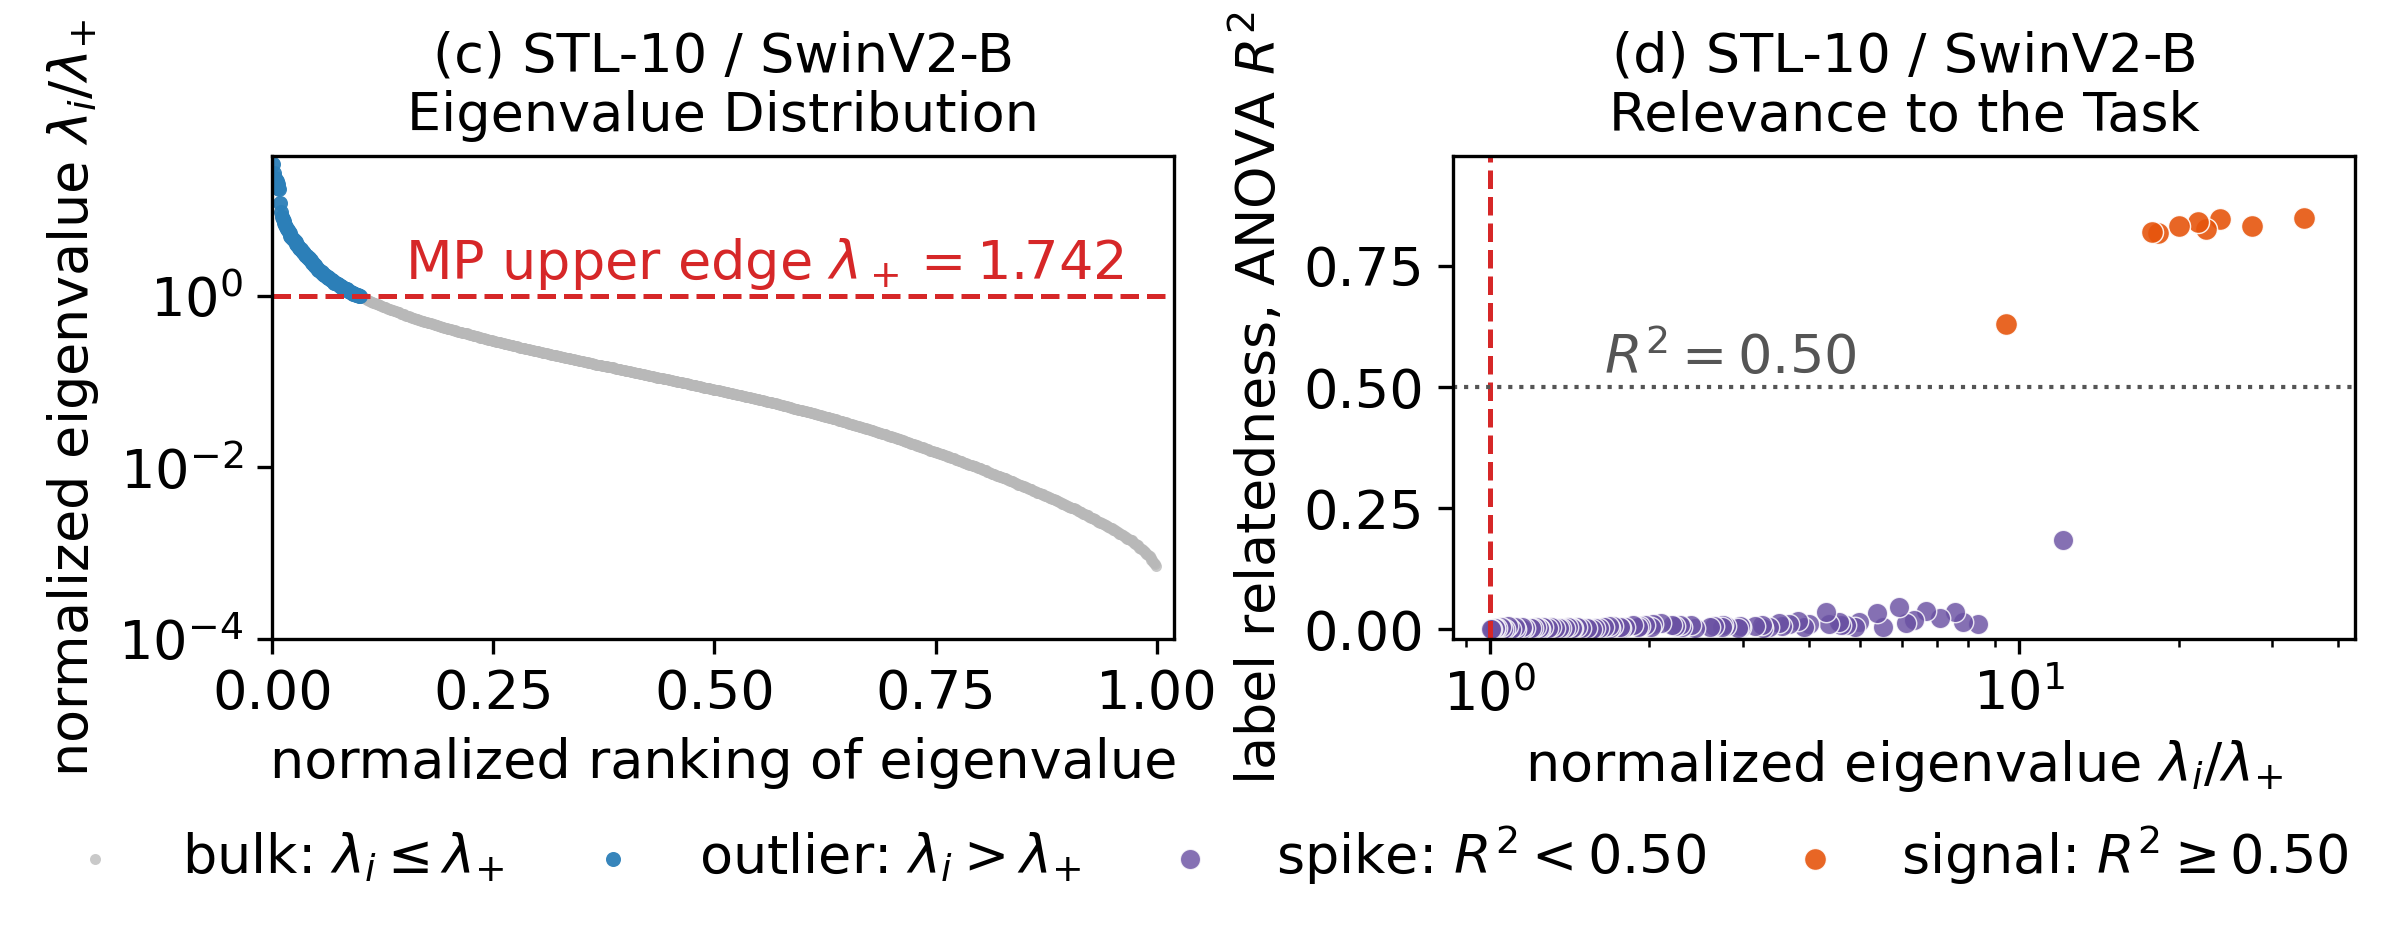

Saved figure to: empirical_evidence_in_image_representation_large.pdf


In [10]:
fig2, (ax2_1, ax2_2) = plt.subplots(1, 2, figsize=(8, 3.2), gridspec_kw=dict(width_ratios=[1.0, 1.0]))

# Bulk / background noise eigenvalues
ax2_1.scatter(rank_frac2[~is_outlier2], ratio2[~is_outlier2],
              s=7, c="#b8b8b8", alpha=0.75, linewidths=0, rasterized=True,
              label=r"bulk: $\lambda_i \leq \lambda_{+}$",)
# Spectral outliers
ax2_1.scatter(rank_frac2[is_outlier2], ratio2[is_outlier2],
              s=13, c="#2c7fb8", alpha=0.95, linewidths=0, rasterized=True,
              label=r"outlier: $\lambda_i > \lambda_{+}$",)
# Marchenko–Pastur (MP) upper edge, normalized to 1
ax2_1.axhline(1.0, color="#d62728", ls="--", lw=1.2)
# Annotate the original, unnormalized MP upper edge. Since y-axis is lambda_i / lambda_+, the edge is always shown at y=1.
ax2_1.text(0.15, 1.12, rf"MP upper edge $\lambda_+={lambda2_plus:.3f}$", color="#d62728", fontsize=13, ha="left", va="bottom")
ax2_1.set_yscale("log")
ax2_1.set_xlim(0, 1.02)
y_max = max(1.3, float(np.max(ratio2)) * 1.25)
y_min = max(float(np.min(ratio2[ratio2 > 0])) * 0.8, 1e-4)
ax2_1.set_ylim(y_min, y_max)
ax2_1.tick_params(axis='both', labelsize=13)
ax2_1.set_xlabel("normalized ranking of eigenvalue", fontsize=13)
ax2_1.set_ylabel(r"normalized eigenvalue $\lambda_i / \lambda_{+}$", fontsize=13)
ax2_1.set_title(f"(c) {stats2['dataset_display']} / {stats2['backbone_display']}\n"
                r"Eigenvalue Distribution", fontsize=13)

# Weakly label-related outliers: nuisance / non-task spikes
ax2_2.scatter(x2[weak2], y2[weak2], s=24, c="#6a51a3", alpha=0.82, edgecolors="white", linewidths=0.35, 
              label=fr"spike: $R^2 < {SIGNAL_R2_THRESH:.2f}$",)
# Strongly label-related outliers: signal
ax2_2.scatter(x2[strong2], y2[strong2], s=28, c="#e6550d", alpha=0.90, edgecolors="white", linewidths=0.35,
              label=fr"signal: $R^2 \geq {SIGNAL_R2_THRESH:.2f}$",)
# MP boundary in normalized coordinates
ax2_2.axvline(1.0, color="#d62728", ls="--", lw=1.2)
# Label-relatedness threshold
ax2_2.axhline(SIGNAL_R2_THRESH, color="#555555", ls=":", lw=1.0)
ax2_2.text(1.64, SIGNAL_R2_THRESH * 1.01, rf"$R^2={SIGNAL_R2_THRESH:.2f}$",
           color="#555555", fontsize=13, ha="left", va="bottom",)
ax2_2.set_xscale("log")
ax2_2.set_ylim(-0.02, min(1.0, max(0.22, float(np.max(y2)) * 1.15)))
if len(x2) > 0: 
    ax2_2.set_xlim(max(0.85, float(np.min(x2)) * 0.85), float(np.max(x2)) * 1.25)
ax2_2.tick_params(axis='both', labelsize=13)
ax2_2.set_xlabel(r"normalized eigenvalue $\lambda_i / \lambda_{+}$", fontsize=13)
ax2_2.set_ylabel(r"label relatedness, ANOVA $R^2$", fontsize=13)
ax2_2.set_title(f"(d) {stats2['dataset_display']} / {stats2['backbone_display']}\n"
                "Relevance to the Task", fontsize=13)

################ Process Legend ################
ax2_1.legend().remove()
ax2_2.legend().remove()
# Collect legend entries from both axes
h1, l1 = ax2_1.get_legend_handles_labels()
h2, l2 = ax2_2.get_legend_handles_labels()
handles = h1 + h2
labels = l1 + l2
# De-duplicate while preserving order
seen = set()
uniq_handles, uniq_labels = [], []
for h, lab in zip(handles, labels):
    if lab not in seen and lab != "":
        uniq_handles.append(h)
        uniq_labels.append(lab)
        seen.add(lab)
# Layout: leave space at the bottom for the figure-level legend
fig2.tight_layout(rect=(0, 0.11, 1, 1))   # bottom margin reserved for legend
# One-row legend under both subplots
fig2.legend(uniq_handles, uniq_labels, loc="lower center",
            bbox_to_anchor=(0.5, 0.01),  # tweak y if needed
            ncol=len(uniq_labels),        # force a single row
            frameon=False, fontsize=13, handlelength=1.6, columnspacing=1.2,)
################################################

plt.show()
fig2.savefig("empirical_evidence_in_image_representation_large.pdf", dpi=300, format="pdf", bbox_inches="tight")
print("Saved figure to: empirical_evidence_in_image_representation_large.pdf")
plt.close(fig2)   # release fig2